In [ ]:
# Streamlit과 ngrok 설치
!pip install streamlit -q
!pip install pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 54.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# 1. 데이터 로드 및 전처리
url = 'https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv'
df = pd.read_csv(url)

df.columns = df.columns.str.strip()
df = df.dropna()

features = ['Adult mortality', 'BMI', 'GDP', 'Alcohol']
X = df[features]
y = df['Life expectancy']

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_sample = X_train_full.sample(n=50, random_state=42)
y_train = y_train_full.loc[train_sample.index]
X_train = train_sample

pipe_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('lr', LinearRegression())
])

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('ridge', Ridge(alpha=1.0))
])

models = {'Linear': pipe_linear, 'Poly': pipe_poly, 'Ridge': pipe_ridge}
metrics = []

for name, pipe in models.items():
    pipe.fit(X_train, y_train)

    pred_train = pipe.predict(X_train)
    pred_test = pipe.predict(X_test)

    r2_train = r2_score(y_train, pred_train)
    r2_test = r2_score(y_test, pred_test)
    mse_train = mean_squared_error(y_train, pred_train)
    mse_test = mean_squared_error(y_test, pred_test)

    if name == 'Linear':
        complexity = X_train.shape[1]
    else:
        complexity = pipe.named_steps['poly'].transform(pipe.named_steps['scaler'].transform(X_train)).shape[1]

    metrics.append({
        'Model': name,
        'Train R^2': r2_train,
        'Test R^2': r2_test,
        'Train MSE': mse_train,
        'Test MSE': mse_test,
        'Complexity (Features)': complexity
    })

    joblib.dump(pipe, f'{name}_model.pkl')

metrics_df = pd.DataFrame(metrics)
joblib.dump(metrics_df, 'metrics.pkl')
print("✅ 모델 및 성능 표 파일(.pkl) 성공적으로 저장되었습니다!")

✅ 모델 및 성능 표 파일(.pkl) 성공적으로 저장되었습니다!


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="기대수명 예측 웹 서비스", layout="wide")
st.title("다중 특성 회귀 모델 기반 기대수명 예측기")
st.markdown("**(Linear vs Polynomial vs Ridge 예측 결과를 실시간으로 비교하고 테스트합니다.)**")

@st.cache_resource
def load_assets():
    models = {
        'Linear': joblib.load('Linear_model.pkl'),
        'Poly': joblib.load('Poly_model.pkl'),
        'Ridge': joblib.load('Ridge_model.pkl')
    }
    metrics_df = joblib.load('metrics.pkl')
    return models, metrics_df

models, metrics_df = load_assets()

st.sidebar.header("입력 파라미터 조절")

adult_mortality = st.sidebar.slider("성인 사망률 (Adult Mortality)", 1, 1000, 150)
bmi = st.sidebar.slider("체질량지수 (BMI)", 1.0, 100.0, 38.0)
gdp = st.sidebar.slider("1인당 GDP", 1.0, 150000.0, 5000.0)
alcohol = st.sidebar.slider("알코올 소비량 (Alcohol)", 0.0, 20.0, 5.0)

st.sidebar.markdown("---")
selected_model_name = st.sidebar.selectbox("로딩할 예측 모델 선택", ['Linear', 'Poly', 'Ridge'])

st.subheader("1. 모델 성능 비교 (과대적합 및 규제 효과 관찰)")
col1, col2 = st.columns(2)

with col1:
    st.markdown("**성능 평가지표 테이블**")
    st.dataframe(metrics_df.style.highlight_max(subset=['Test R^2'], color='lightgreen'))

with col2:
    st.markdown("**Test 점수 비교 (막대그래프)**")
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(x='Model', y='Test R^2', data=metrics_df, ax=ax, palette='viridis')
    st.pyplot(fig)

st.markdown("---")
st.subheader(f"2. 실시간 기대수명 예측 결과 (선택된 모델: {selected_model_name})")

input_data = pd.DataFrame({
    'Adult mortality': [adult_mortality],
    'BMI': [bmi],
    'GDP': [gdp],
    'Alcohol': [alcohol]
})

model = models[selected_model_name]
prediction = model.predict(input_data)[0]

st.markdown(
    f"<h1 style='text-align: center; color: #4CAF50; background-color: #f0f2f6; padding: 20px; border-radius: 10px;'>"
    f"예측된 기대수명: {prediction:.2f} 세</h1>",
    unsafe_allow_html=True
)

Overwriting app.py


In [ ]:
!pip install streamlit pyngrok -q
from pyngrok import ngrok
import os
import time

# 1. 혹시 열려있을지 모르는 기존 터널 모두 닫기
ngrok.kill()

# 2. 인증 토큰 설정
ngrok.set_auth_token("3DyfPK6BNTtkNjNa0N0xCFY2NHf_3TK2JfkGDuGbWFQktNdYS")

# 3. Streamlit 실행 (서버 주소를 명시적으로 127.0.0.1로 고정하여 백그라운드 구동)
os.system("nohup streamlit run app.py --server.address 127.0.0.1 --server.port 8501 > /dev/null 2>&1 &")

# Streamlit 서버가 완전히 부팅될 때까지 3초간 대기
time.sleep(3)

# 4. ngrok 터널 연결 (8501 포트 열기)
public_url = ngrok.connect(8501, bind_tls=True)

print("=" * 60)
print(f"성공적으로 배포되었습니다! 아래 링크를 클릭하세요:\n{public_url}")
print("=" * 60)

성공적으로 배포되었습니다! 아래 링크를 클릭하세요:
NgrokTunnel: "https://catapult-ethics-riot.ngrok-free.dev" -> "http://localhost:8501"


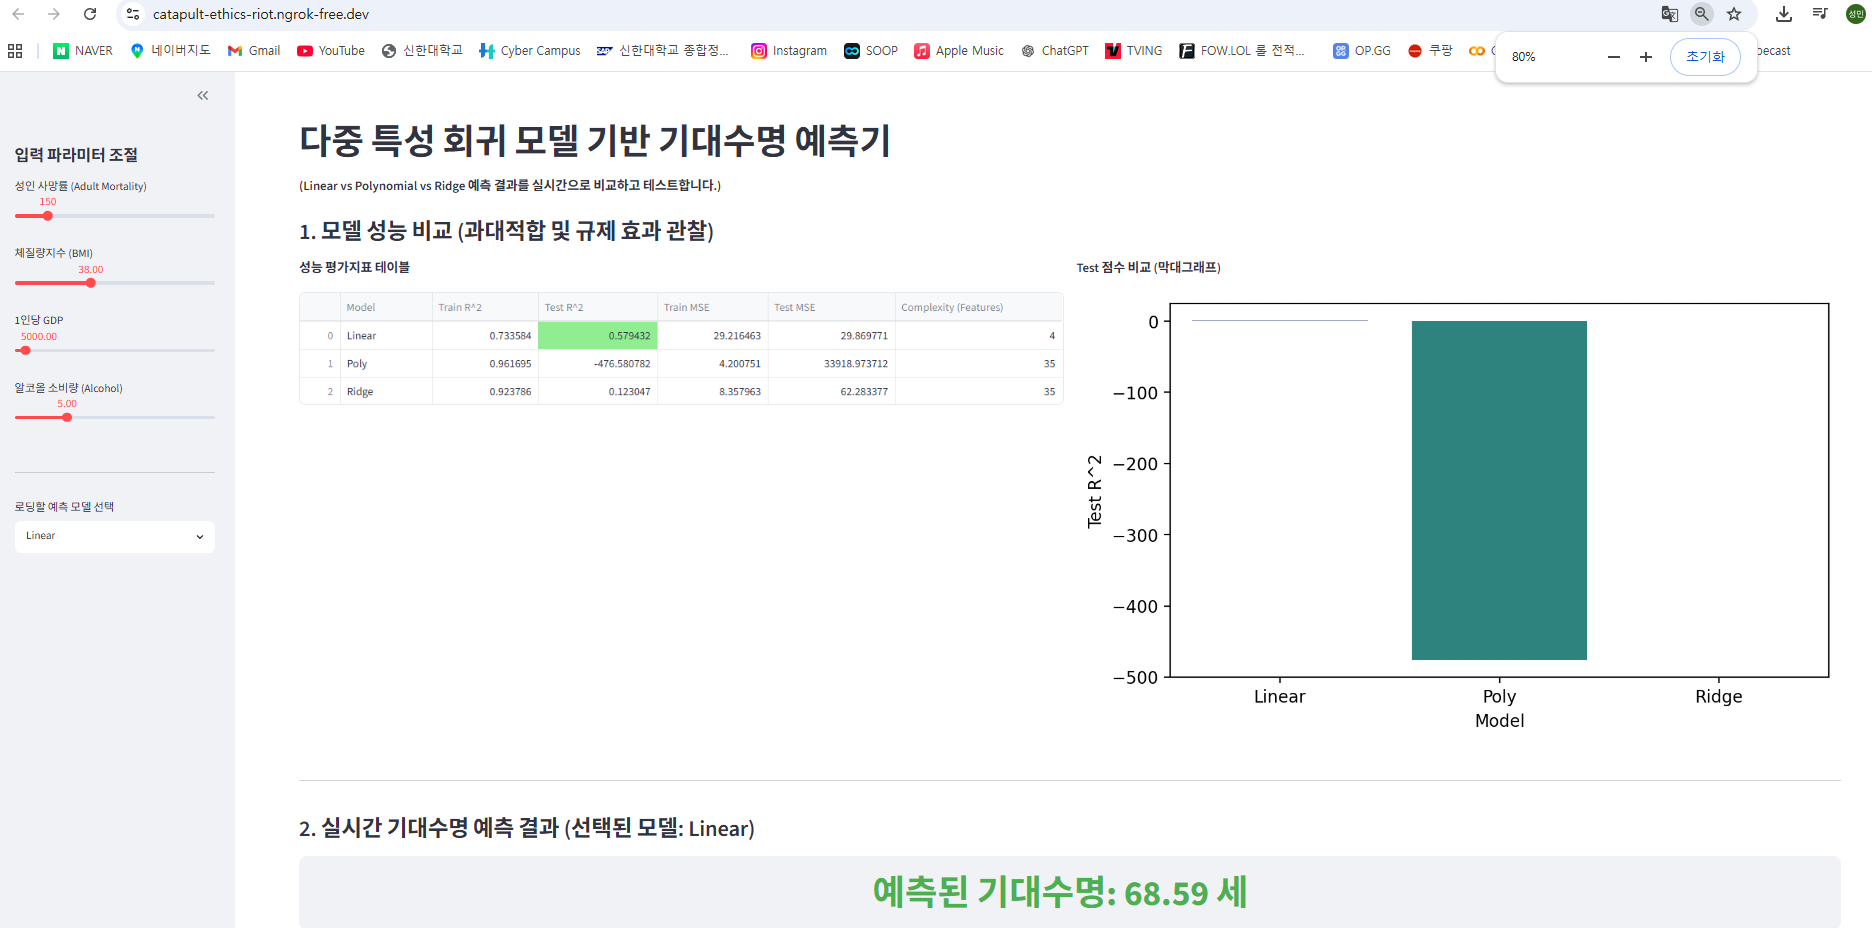